In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df =pd.read_csv('/content/drive/MyDrive/Air Pollution/Final Air Quality Dataset.csv')
df

,Unnamed: 0,O3 (ppb),CO (ppm),SO2 (μg/m³),NO2 (μg/m³),PM2.5 (μg/m³),PM10 (μg/m³),Polluted
0,1,40,0.3,15,35,20,45,0
1,2,20,0.4,18,45,30,55,0
2,3,10,0.2,10,25,15,40,0
3,4,5,0.6,25,50,35,60,0
4,5,50,0.7,30,55,40,70,1
...,...,...,...,...,...,...,...,...
4524,4525,23,0.0,8,73,79,79,0
4525,4526,65,0.6,102,10,60,50,1
4526,4527,69,0.7,122,130,69,70,1
4527,4528,111,0.0,100,55,21,42,1


In [ ]:
#df = df.drop('Unnamed: 0', axis=1)
df

,Unnamed: 0,O3 (ppb),CO (ppm),SO2 (μg/m³),NO2 (μg/m³),PM2.5 (μg/m³),PM10 (μg/m³),Polluted
0,1,40,0.3,15,35,20,45,0
1,2,20,0.4,18,45,30,55,0
2,3,10,0.2,10,25,15,40,0
3,4,5,0.6,25,50,35,60,0
4,5,50,0.7,30,55,40,70,1
...,...,...,...,...,...,...,...,...
4524,4525,23,0.0,8,73,79,79,0
4525,4526,65,0.6,102,10,60,50,1
4526,4527,69,0.7,122,130,69,70,1
4527,4528,111,0.0,100,55,21,42,1


Date Preprocessing & Data Visualization

In [ ]:
df.columns

Index(['Unnamed: 0', 'O3 (ppb)', 'CO (ppm)', 'SO2 (μg/m³)', 'NO2 (μg/m³)',
       'PM2.5 (μg/m³)', 'PM10 (μg/m³)', 'Polluted'],
      dtype='object')

In [ ]:
# Shape of the dataset
df.shape

(4529, 8)

In [ ]:
# Viewing the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4529 entries, 0 to 4528
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4529 non-null   int64  
 1   O3 (ppb)       4529 non-null   int64  
 2   CO (ppm)       4529 non-null   float64
 3   SO2 (μg/m³)    4529 non-null   int64  
 4   NO2 (μg/m³)    4529 non-null   int64  
 5   PM2.5 (μg/m³)  4529 non-null   int64  
 6   PM10 (μg/m³)   4529 non-null   int64  
 7   Polluted       4529 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 283.2 KB


In [ ]:
# Let's look at the columns dtypes again
print(df.dtypes)

Unnamed: 0         int64
O3 (ppb)           int64
CO (ppm)         float64
SO2 (μg/m³)        int64
NO2 (μg/m³)        int64
PM2.5 (μg/m³)      int64
PM10 (μg/m³)       int64
Polluted           int64
dtype: object


In [ ]:
#Remove null values
df = df.dropna()

In [ ]:
#Checking Null values
df.isnull().sum()

Unnamed: 0       0
O3 (ppb)         0
CO (ppm)         0
SO2 (μg/m³)      0
NO2 (μg/m³)      0
PM2.5 (μg/m³)    0
PM10 (μg/m³)     0
Polluted         0
dtype: int64

In [ ]:
# Duplicate Variables
df.duplicated().sum()

0

In [ ]:
# Summary for numerical data
df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,4529.0,2265.000000,1307.554014,1.0,1133.0,2265.0,3397.0,4529.0
O3 (ppb),4529.0,78.831309,53.451518,5.0,38.0,72.0,107.0,250.0
CO (ppm),4529.0,0.501214,0.289168,0.0,0.2,0.5,0.7,1.0
SO2 (μg/m³),4529.0,77.529256,41.881206,5.0,41.0,78.0,113.0,150.0
NO2 (μg/m³),4529.0,69.979907,34.615777,10.0,40.0,70.0,100.0,130.0
PM2.5 (μg/m³),4529.0,51.401855,27.695389,3.0,28.0,52.0,75.0,99.0
PM10 (μg/m³),4529.0,52.627512,27.751503,5.0,28.0,53.0,77.0,100.0
Polluted,4529.0,0.672775,0.469252,0.0,0.0,1.0,1.0,1.0


In [ ]:
df['Polluted'].value_counts()

1    3047
0    1482
Name: Polluted, dtype: int64

Text(0.5, 1.0, 'Air Pollution Dataset Distribution')

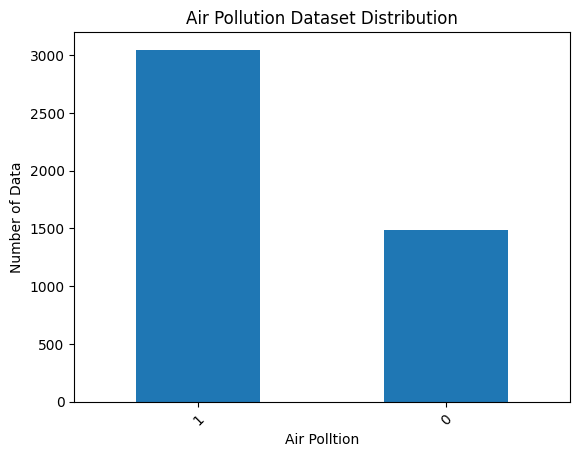

In [ ]:
# Air Pollution Dataset Distribution
df['Polluted'].value_counts().plot(kind='bar')
plt.xlabel("Air Polltion")
plt.ylabel("Number of Data")
plt.xticks(rotation =45)
plt.title("Air Pollution Dataset Distribution")


In [ ]:
#Creating Training and Testing Dataset
from sklearn.model_selection import train_test_split

# Creating the independent and dependent variables
X = df.drop('Polluted',axis=1)
y = df['Polluted']

# Creating the training and test set

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Importing required libraries
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


Logistic Regression

In [ ]:
# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Logistic Regression Model Evaluation
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_pred)
print("\n")
print("\n\tLogistic Regression Accuracy:", logreg_accuracy)
print("\n")
print(classification_report(y_test, logreg_pred))




	Logistic Regression Accuracy: 0.8057395143487859


              precision    recall  f1-score   support

           0       0.75      0.64      0.69       306
           1       0.83      0.89      0.86       600

    accuracy                           0.81       906
   macro avg       0.79      0.77      0.77       906
weighted avg       0.80      0.81      0.80       906



Support Vector Machine

In [ ]:
# Support Vector Machine (SVM)
svm_classifier = SVC()
svm_classifier.fit(X_train, y_train)

SVC()

In [ ]:
# Support Vector Machine (SVM)
svm_pred = svm_classifier.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("\n")
print("\n\tSVM Accuracy:", svm_accuracy)
print("\n")
print(classification_report(y_test, svm_pred))




	SVM Accuracy: 0.6622516556291391


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       306
           1       0.66      1.00      0.80       600

    accuracy                           0.66       906
   macro avg       0.33      0.50      0.40       906
weighted avg       0.44      0.66      0.53       906



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Neural Network

Feedforward neural network(FNN) AKA Multi-Layer Perceptron (MLP)

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler




# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a simple neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



In [ ]:
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
102/102 [==============================] - 2s 7ms/step - loss: 0.4705 - accuracy: 0.8086 - val_loss: 0.3999 - val_accuracy: 0.7989
Epoch 2/20
102/102 [==============================] - 0s 4ms/step - loss: 0.3571 - accuracy: 0.8396 - val_loss: 0.3797 - val_accuracy: 0.7961
Epoch 3/20
102/102 [==============================] - 0s 4ms/step - loss: 0.3335 - accuracy: 0.8429 - val_loss: 0.3460 - val_accuracy: 0.8320
Epoch 4/20
102/102 [==============================] - 0s 4ms/step - loss: 0.3178 - accuracy: 0.8494 - val_loss: 0.3300 - val_accuracy: 0.8347
Epoch 5/20
102/102 [==============================] - 0s 4ms/step - loss: 0.3024 - accuracy: 0.8601 - val_loss: 0.3229 - val_accuracy: 0.8512
Epoch 6/20
102/102 [==============================] - 0s 4ms/step - loss: 0.2893 - accuracy: 0.8684 - val_loss: 0.3040 - val_accuracy: 0.8567
Epoch 7/20
102/102 [==============================] - 0s 3ms/step - loss: 0.2776 - accuracy: 0.8733 - val_loss: 0.3132 - val_accuracy: 0.8595
Epoch 

In [ ]:
# Evaluate the model
y_pred = model.predict(X_test_scaled)
y_pred_classes = (y_pred > 0.5).astype(int)
print("\n")
print(classification_report(y_test, y_pred_classes))


29/29 [==============================] - 0s 2ms/step


              precision    recall  f1-score   support

           0       0.87      0.80      0.83       306
           1       0.90      0.94      0.92       600

    accuracy                           0.89       906
   macro avg       0.88      0.87      0.88       906
weighted avg       0.89      0.89      0.89       906



Save the trained model

In [ ]:
!pip install joblib
import joblib

# Save the model using joblib
model_filename = 'Air_Quality_NN_model.pkl'
joblib.dump(model, model_filename)

print(f"Neural network model saved as '{model_filename}'")

Neural network model saved as 'Air_Quality_NN_model.pkl'


Save the model architecture in a JSON file

In [ ]:
import json
# Save the model architecture in a JSON file
model_architecture_filename = 'Air_Quality_NN_model_architecture.json'
model_json = model.to_json()
with open(model_architecture_filename, 'w') as json_file:
    json_file.write(model_json)

print(f"Neural network model architecture saved as '{model_architecture_filename}'")


Neural network model architecture saved as 'Air_Quality_NN_model_architecture.json'
